In [24]:
# ==============================
# DATA PROCESSING
# ==============================
import pandas as pd
import numpy as np

# ==============================
# VISUALIZATION
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns


# ==============================
# MACHINE LEARNING (sklearn)
# ==============================
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    r2_score
)

# ==============================
# STATISTICS 
# ==============================
import statsmodels.api as sm

# ==============================
# WARNINGS (clean output)
# ==============================
import warnings
warnings.filterwarnings("ignore")

In [25]:
import pandas as pd

df = pd.read_csv("panel_dataset.csv")

In [26]:
print(df.shape)
print(df.columns)
df.head()
df.info()

(21303, 15)
Index(['repo', 'repo_age_months', 'stars', 'forks', 'days_since_last_commit',
       'number_of_contributors', 'number_of_commits',
       'number_of_new_contributors', 'number_of_open_PRs',
       'number_of_closed_PRs', 'number_of_merged_PRs', 'number_of_open_issues',
       'number_of_closed_issues', 'year', 'month'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 21303 entries, 0 to 21302
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   repo                        21303 non-null  str    
 1   repo_age_months             21303 non-null  int64  
 2   stars                       21303 non-null  int64  
 3   forks                       21303 non-null  int64  
 4   days_since_last_commit      20644 non-null  float64
 5   number_of_contributors      21303 non-null  int64  
 6   number_of_commits           21303 non-null  int64  
 7   number_of_new_contributors  21

In [27]:
import os
import pandas as pd
import numpy as np

# =========================================================
# 1. CREATE OUTPUT FOLDER
# =========================================================
OUTPUT_DIR = "EDA"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================================================
# 2. LOAD DATA
# =========================================================
df = pd.read_csv("panel_dataset.csv")

# =========================================================
# 3. CHECK BASIC INFO
# =========================================================
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# =========================================================
# 4. SELECT NUMERICAL COLUMNS FOR DESCRIPTIVE ANALYSIS
# =========================================================
numeric_cols = [
    "repo_age_months",
    "stars",
    "forks",
    "days_since_last_commit",
    "number_of_contributors",
    "number_of_commits",
    "number_of_new_contributors",
    "number_of_open_PRs",
    "number_of_closed_PRs",
    "number_of_merged_PRs",
    "number_of_open_issues",
    "number_of_closed_issues",
    "year",
    "month"
]

# Chỉ giữ những cột thực sự tồn tại trong file
numeric_cols = [col for col in numeric_cols if col in df.columns]

print("\nNumerical columns used for EDA:")
print(numeric_cols)

# =========================================================
# 5. OPTIONAL: CREATE DERIVED VARIABLES
# =========================================================
if "number_of_open_issues" in df.columns and "number_of_closed_issues" in df.columns:
    df["total_issues"] = (
        df["number_of_open_issues"].fillna(0)
        + df["number_of_closed_issues"].fillna(0)
    )

if "number_of_open_PRs" in df.columns and "number_of_closed_PRs" in df.columns:
    df["total_prs"] = (
        df["number_of_open_PRs"].fillna(0)
        + df["number_of_closed_PRs"].fillna(0)
    )

if all(col in df.columns for col in ["number_of_commits", "number_of_closed_issues", "number_of_merged_PRs"]):
    df["total_activity"] = (
        df["number_of_commits"].fillna(0)
        + df["number_of_closed_issues"].fillna(0)
        + df["number_of_merged_PRs"].fillna(0)
    )

# Thêm các biến mới nếu có
for extra_col in ["total_issues", "total_prs", "total_activity"]:
    if extra_col in df.columns and extra_col not in numeric_cols:
        numeric_cols.append(extra_col)

# =========================================================
# 6. FUNCTION TO CALCULATE DETAILED DESCRIPTIVE STATISTICS
# =========================================================
def descriptive_summary(dataframe, columns):
    summary_rows = []

    for col in columns:
        s = dataframe[col].dropna()

        if len(s) == 0:
            continue

        q1 = s.quantile(0.25)
        q2 = s.quantile(0.50)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_count = ((s < lower_bound) | (s > upper_bound)).sum()
        outlier_pct = (outlier_count / len(s)) * 100

        zero_count = (s == 0).sum()
        zero_pct = (zero_count / len(s)) * 100

        missing_count = dataframe[col].isna().sum()
        missing_pct = (missing_count / len(dataframe)) * 100

        skewness = s.skew()

        summary_rows.append({
            "variable": col,
            "count": len(s),
            "missing_count": missing_count,
            "missing_pct": round(missing_pct, 2),
            "mean": round(s.mean(), 3),
            "median": round(q2, 3),
            "std": round(s.std(), 3),
            "min": round(s.min(), 3),
            "Q1": round(q1, 3),
            "Q3": round(q3, 3),
            "max": round(s.max(), 3),
            "IQR": round(iqr, 3),
            "skewness": round(skewness, 3),
            "zero_count": int(zero_count),
            "zero_pct": round(zero_pct, 2),
            "outlier_count_IQR": int(outlier_count),
            "outlier_pct_IQR": round(outlier_pct, 2)
        })

    return pd.DataFrame(summary_rows)

# =========================================================
# 7. GENERATE DESCRIPTIVE STATISTICS TABLE
# =========================================================
desc_stats = descriptive_summary(df, numeric_cols)
desc_stats = desc_stats.sort_values("variable").reset_index(drop=True)

print("\n========== DESCRIPTIVE STATISTICS ==========")
print(desc_stats)

desc_stats_path = os.path.join(OUTPUT_DIR, "descriptive_statistics_summary.csv")
desc_stats.to_csv(desc_stats_path, index=False)
print(f"\nSaved: {desc_stats_path}")

# =========================================================
# 8. STANDARD DESCRIBE TABLE
# =========================================================
basic_describe = df[numeric_cols].describe().T
basic_describe["median"] = df[numeric_cols].median()
basic_describe["skewness"] = df[numeric_cols].skew()
basic_describe["zero_pct"] = (df[numeric_cols] == 0).sum() / len(df) * 100

print("\n========== BASIC DESCRIBE TABLE ==========")
print(basic_describe)

basic_describe_path = os.path.join(OUTPUT_DIR, "basic_describe_table.csv")
basic_describe.to_csv(basic_describe_path)
print(f"Saved: {basic_describe_path}")

# =========================================================
# 9. IDENTIFY HEAVILY SKEWED VARIABLES
# =========================================================
desc_stats["abs_skewness"] = desc_stats["skewness"].abs()

high_skew = desc_stats[desc_stats["abs_skewness"] > 1].sort_values(
    "abs_skewness", ascending=False
)

very_high_skew = desc_stats[desc_stats["abs_skewness"] > 2].sort_values(
    "abs_skewness", ascending=False
)

print("\n========== HIGHLY SKEWED VARIABLES (|skew| > 1) ==========")
print(high_skew[["variable", "skewness"]])

print("\n========== VERY HIGHLY SKEWED VARIABLES (|skew| > 2) ==========")
print(very_high_skew[["variable", "skewness"]])

high_skew_path = os.path.join(OUTPUT_DIR, "high_skew_variables.csv")
very_high_skew_path = os.path.join(OUTPUT_DIR, "very_high_skew_variables.csv")

high_skew[["variable", "skewness"]].to_csv(high_skew_path, index=False)
very_high_skew[["variable", "skewness"]].to_csv(very_high_skew_path, index=False)

print(f"Saved: {high_skew_path}")
print(f"Saved: {very_high_skew_path}")

# =========================================================
# 10. IDENTIFY VARIABLES WITH MANY ZEROS
# =========================================================
many_zeros = desc_stats[desc_stats["zero_pct"] >= 50].sort_values(
    "zero_pct", ascending=False
)

print("\n========== VARIABLES WITH MANY ZERO VALUES (>= 50%) ==========")
print(many_zeros[["variable", "zero_count", "zero_pct"]])

many_zeros_path = os.path.join(OUTPUT_DIR, "many_zero_variables.csv")
many_zeros[["variable", "zero_count", "zero_pct"]].to_csv(many_zeros_path, index=False)
print(f"Saved: {many_zeros_path}")

# =========================================================
# 11. IDENTIFY VARIABLES WITH MANY OUTLIERS
# =========================================================
many_outliers = desc_stats[desc_stats["outlier_pct_IQR"] >= 5].sort_values(
    "outlier_pct_IQR", ascending=False
)

print("\n========== VARIABLES WITH NOTICEABLE OUTLIERS (IQR method, >= 5%) ==========")
print(many_outliers[["variable", "outlier_count_IQR", "outlier_pct_IQR"]])

many_outliers_path = os.path.join(OUTPUT_DIR, "many_outlier_variables.csv")
many_outliers[["variable", "outlier_count_IQR", "outlier_pct_IQR"]].to_csv(many_outliers_path, index=False)
print(f"Saved: {many_outliers_path}")

# =========================================================
# 12. EXPORT CLEAN TABLE FOR PAPER
# =========================================================
paper_table = desc_stats[[
    "variable", "mean", "median", "std", "min", "Q1", "Q3", "max",
    "skewness", "zero_pct", "outlier_pct_IQR"
]]

paper_table_path = os.path.join(OUTPUT_DIR, "paper_descriptive_table.csv")
paper_table.to_csv(paper_table_path, index=False)
print(f"\nSaved: {paper_table_path}")

# =========================================================
# 13. SAVE QUICK TEXT INTERPRETATION
# =========================================================
interpretation_lines = []
interpretation_lines.append("QUICK INTERPRETATION OF DESCRIPTIVE STATISTICS\n")

for _, row in desc_stats.iterrows():
    var = row["variable"]
    mean_ = row["mean"]
    median_ = row["median"]
    skew_ = row["skewness"]
    zero_ = row["zero_pct"]
    outlier_ = row["outlier_pct_IQR"]

    comments = []

    if mean_ > median_:
        comments.append("mean > median, suggesting right-skewness")
    elif mean_ < median_:
        comments.append("mean < median, suggesting left-skewness")
    else:
        comments.append("mean ≈ median")

    if abs(skew_) > 2:
        comments.append("very strong skew")
    elif abs(skew_) > 1:
        comments.append("strong skew")
    elif abs(skew_) > 0.5:
        comments.append("moderate skew")
    else:
        comments.append("relatively symmetric")

    if zero_ >= 50:
        comments.append("many zero values")
    elif zero_ >= 20:
        comments.append("a noticeable share of zero values")

    if outlier_ >= 10:
        comments.append("substantial outliers")
    elif outlier_ >= 5:
        comments.append("some outliers")

    interpretation_lines.append(f"- {var}: " + "; ".join(comments))

interpretation_path = os.path.join(OUTPUT_DIR, "quick_interpretation.txt")
with open(interpretation_path, "w", encoding="utf-8") as f:
    for line in interpretation_lines:
        f.write(line + "\n")

print(f"Saved: {interpretation_path}")

# =========================================================
# 14. SAVE COLUMN LIST
# =========================================================
column_list_path = os.path.join(OUTPUT_DIR, "numeric_columns_used.txt")
with open(column_list_path, "w", encoding="utf-8") as f:
    for col in numeric_cols:
        f.write(col + "\n")

print(f"Saved: {column_list_path}")

print("\nAll descriptive EDA outputs have been saved in folder:", OUTPUT_DIR)

Dataset shape: (21303, 15)

Columns:
['repo', 'repo_age_months', 'stars', 'forks', 'days_since_last_commit', 'number_of_contributors', 'number_of_commits', 'number_of_new_contributors', 'number_of_open_PRs', 'number_of_closed_PRs', 'number_of_merged_PRs', 'number_of_open_issues', 'number_of_closed_issues', 'year', 'month']

Numerical columns used for EDA:
['repo_age_months', 'stars', 'forks', 'days_since_last_commit', 'number_of_contributors', 'number_of_commits', 'number_of_new_contributors', 'number_of_open_PRs', 'number_of_closed_PRs', 'number_of_merged_PRs', 'number_of_open_issues', 'number_of_closed_issues', 'year', 'month']

========== DESCRIPTIVE STATISTICS ==========
                      variable  count  missing_count  missing_pct       mean  \
0       days_since_last_commit  20644            659         3.09     38.547   
1                        forks  21303              0         0.00   4418.399   
2                        month  21303              0         0.00      6.827

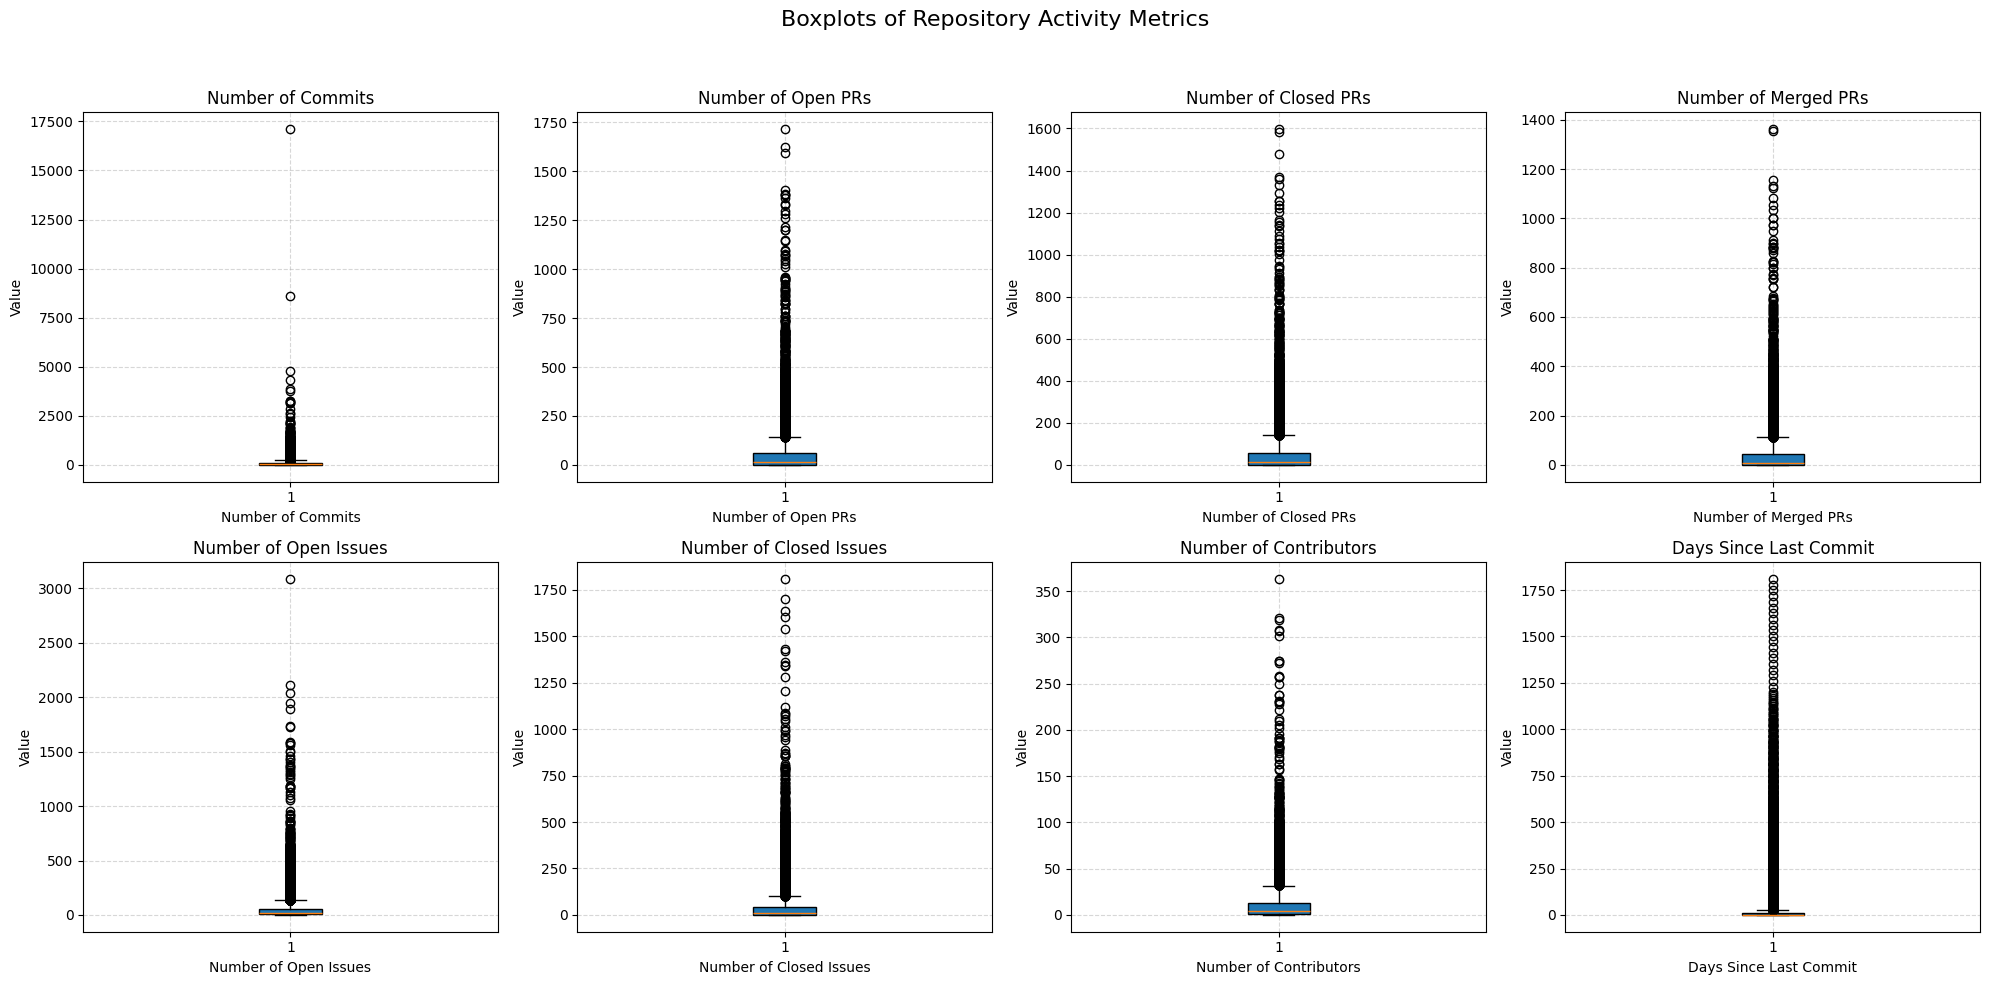

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# =========================================
# 1. LOAD DATA
# =========================================
df = pd.read_csv("panel_dataset.csv")

# =========================================
# 2. CHỌN CÁC BIẾN CẦN VẼ
# =========================================
cols_to_plot = [
    "number_of_commits",
    "number_of_open_PRs",
    "number_of_closed_PRs",
    "number_of_merged_PRs",
    "number_of_open_issues",
    "number_of_closed_issues",
    "number_of_contributors",
    "days_since_last_commit"
]

# Label đẹp hơn để hiện trên biểu đồ
labels = {
    "number_of_commits": "Number of Commits",
    "number_of_open_PRs": "Number of Open PRs",
    "number_of_closed_PRs": "Number of Closed PRs",
    "number_of_merged_PRs": "Number of Merged PRs",
    "number_of_open_issues": "Number of Open Issues",
    "number_of_closed_issues": "Number of Closed Issues",
    "number_of_contributors": "Number of Contributors",
    "days_since_last_commit": "Days Since Last Commit"
}

# =========================================
# 3. TẠO LAYOUT 4 BIỂU ĐỒ MỖI HÀNG
# =========================================
n_cols = 4
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
axes = axes.flatten()

# =========================================
# 4. VẼ BOXPLOT
# =========================================
for i, col in enumerate(cols_to_plot):
    data = df[col].dropna()

    axes[i].boxplot(data, vert=True, patch_artist=True)
    axes[i].set_title(labels[col], fontsize=12)
    axes[i].set_ylabel("Value", fontsize=10)
    axes[i].set_xlabel(labels[col], fontsize=10)
    axes[i].grid(True, linestyle="--", alpha=0.5)

# Xóa các ô trống nếu có
for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

# =========================================
# 5. HIỂN THỊ
# =========================================
plt.suptitle("Boxplots of Repository Activity Metrics", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

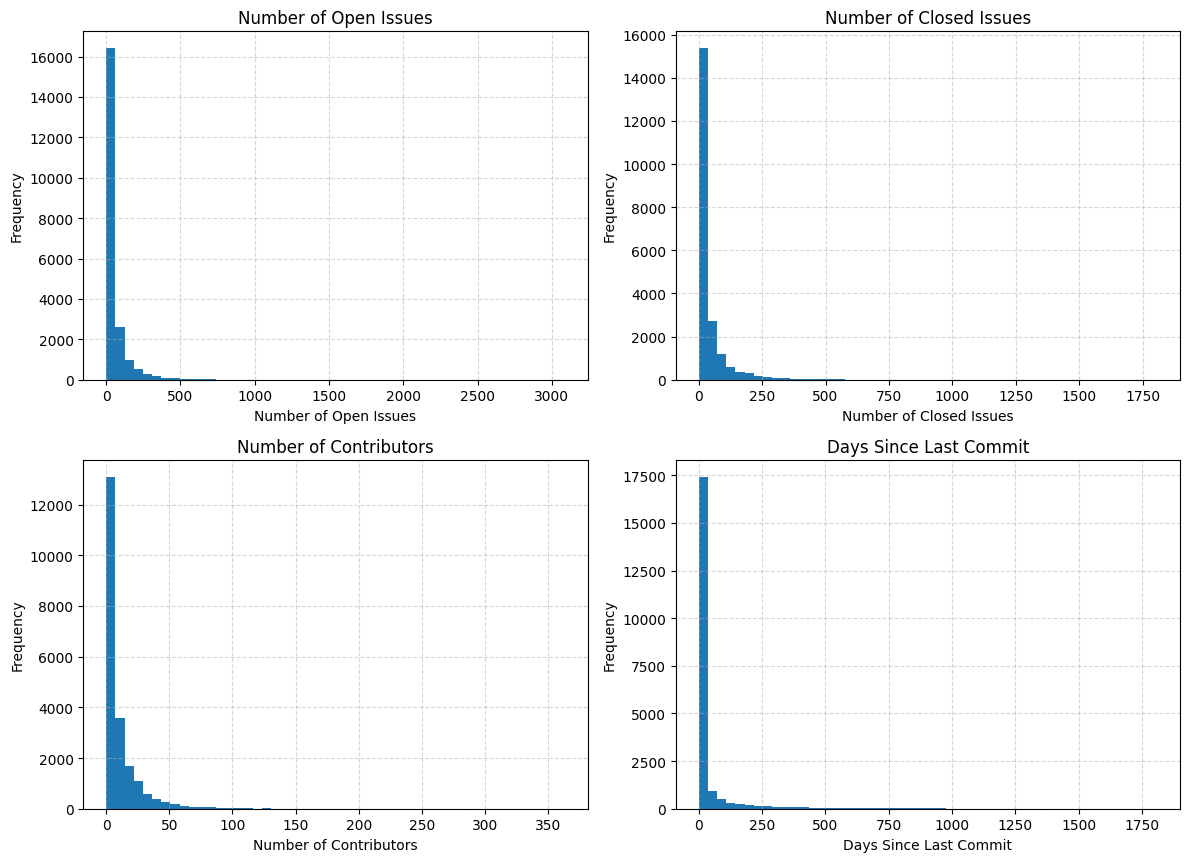

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# =========================================
# 1. LOAD DATA
# =========================================
df = pd.read_csv("panel_dataset.csv")

# =========================================
# 2. CHOOSE FEATURES
# =========================================
cols_to_plot = [
    
    "number_of_open_issues",
    "number_of_closed_issues",
    "number_of_contributors",
    "days_since_last_commit"
]

labels = {
    "number_of_open_issues": "Number of Open Issues",
    "number_of_closed_issues": "Number of Closed Issues",
    "number_of_contributors": "Number of Contributors",
    "days_since_last_commit": "Days Since Last Commit"
}

# =========================================
# 3. LAYOUT 2 COLS
# =========================================
n_cols = 2
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 9))
axes = axes.flatten()

# =========================================
# 4. DRAW HISTOGRAM
# =========================================
for i, col in enumerate(cols_to_plot):
    data = df[col].dropna()

    axes[i].hist(data, bins=50)
    axes[i].set_title(labels[col], fontsize=12)
    axes[i].set_xlabel(labels[col], fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)
    axes[i].grid(True, linestyle="--", alpha=0.5)

for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

# =========================================
# 5. SHOW
# =========================================
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("histograms_raw2.png", dpi=300, bbox_inches="tight")
plt.show()


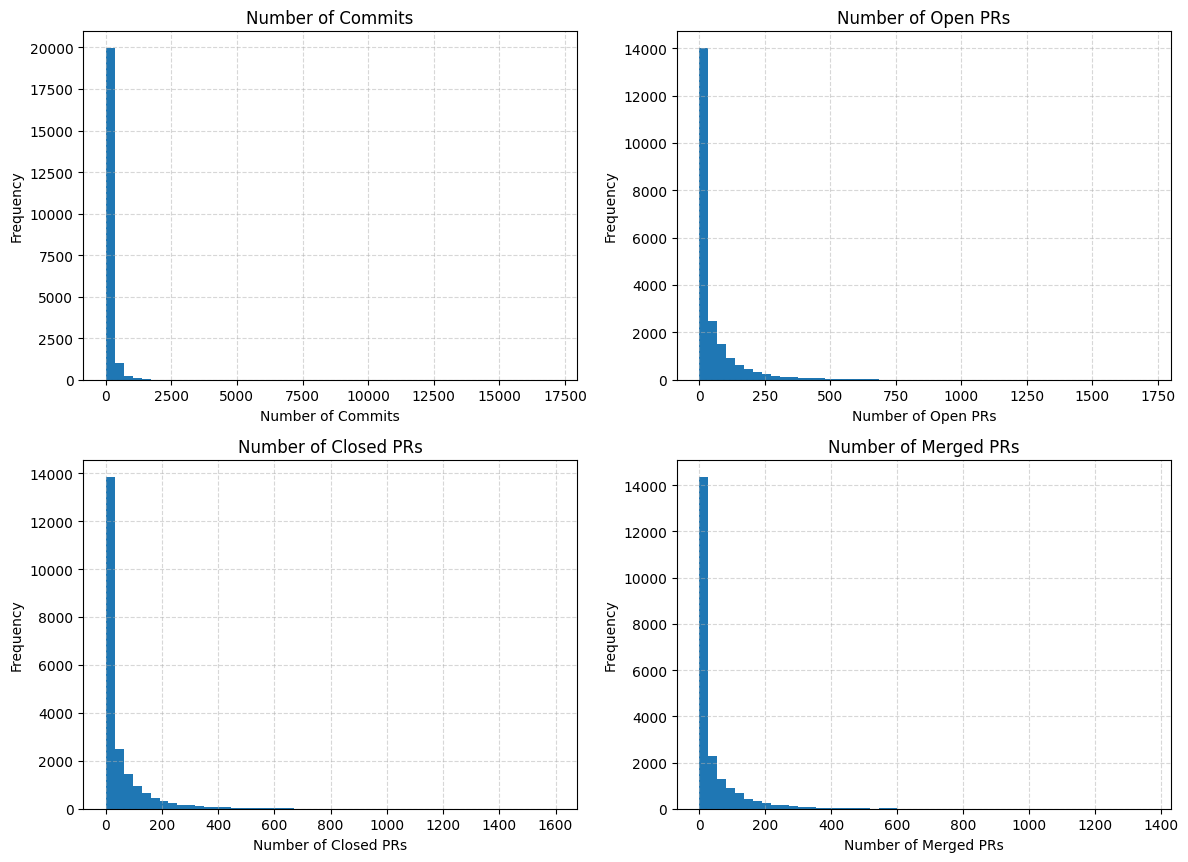

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# =========================================
# 1. LOAD DATA
# =========================================
df = pd.read_csv("panel_dataset.csv")

# =========================================
# 2. CHOOSE FEATURES
# =========================================
cols_to_plot = [
    "number_of_commits",
    "number_of_open_PRs",
    "number_of_closed_PRs",
    "number_of_merged_PRs",
]

labels = {
    "number_of_commits": "Number of Commits",
    "number_of_open_PRs": "Number of Open PRs",
    "number_of_closed_PRs": "Number of Closed PRs",
    "number_of_merged_PRs": "Number of Merged PRs"
}

# =========================================
# 3. LAYOUT 2 COLS
# =========================================
n_cols = 2
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 9))
axes = axes.flatten()

# =========================================
# 4. DRAW HISTOGRAM
# =========================================
for i, col in enumerate(cols_to_plot):
    data = df[col].dropna()

    axes[i].hist(data, bins=50)
    axes[i].set_title(labels[col], fontsize=12)
    axes[i].set_xlabel(labels[col], fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)
    axes[i].grid(True, linestyle="--", alpha=0.5)

for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

# =========================================
# 5. SHOW
# =========================================

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("histograms_raw1.png", dpi=300, bbox_inches="tight")
plt.show()


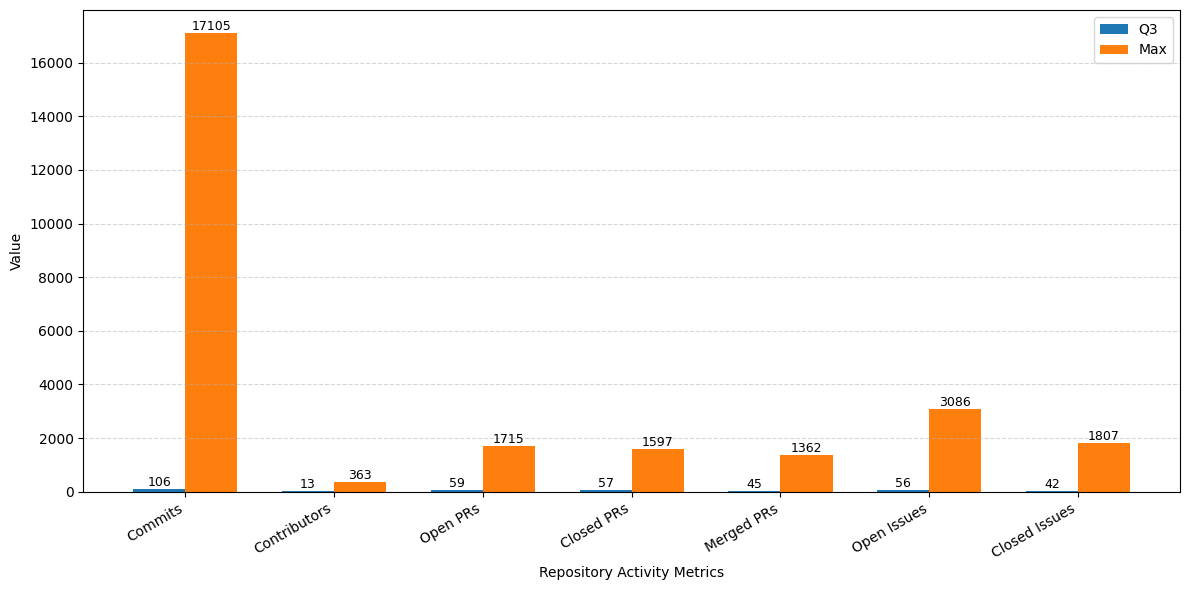

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================
# 1. LOAD DATA
# =========================================
df = pd.read_csv("panel_dataset.csv")

# =========================================
# 2. CHOOSE FEATURE
# =========================================
selected_vars = [
    "number_of_commits",
    "number_of_contributors",
    "number_of_open_PRs",
    "number_of_closed_PRs",
    "number_of_merged_PRs",
    "number_of_open_issues",
    "number_of_closed_issues"
]

labels = {
    "number_of_commits": "Commits",
    "number_of_contributors": "Contributors",
    "number_of_open_PRs": "Open PRs",
    "number_of_closed_PRs": "Closed PRs",
    "number_of_merged_PRs": "Merged PRs",
    "number_of_open_issues": "Open Issues",
    "number_of_closed_issues": "Closed Issues"
}

# =========================================
# 3. CALCULATE Q3 AND MAX
# =========================================
q3_values = [df[col].quantile(0.75) for col in selected_vars]
max_values = [df[col].max() for col in selected_vars]
x_labels = [labels[col] for col in selected_vars]

# =========================================
# 4. DRAW GROUPED BAR CHART
# =========================================
x = np.arange(len(selected_vars))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, q3_values, width, label="Q3")
plt.bar(x + width/2, max_values, width, label="Max")

plt.xticks(x, x_labels, rotation=30, ha="right")
plt.ylabel("Value")
plt.xlabel("Repository Activity Metrics")

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

# =========================================
# 5. ADD LABEL
# =========================================
for i, v in enumerate(q3_values):
    plt.text(i - width/2, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9)

for i, v in enumerate(max_values):
    plt.text(i + width/2, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9)

# =========================================
# 6. Save
# =========================================
plt.tight_layout()
plt.savefig("grouped_bar_q3_max.png", dpi=300, bbox_inches="tight")
plt.show()

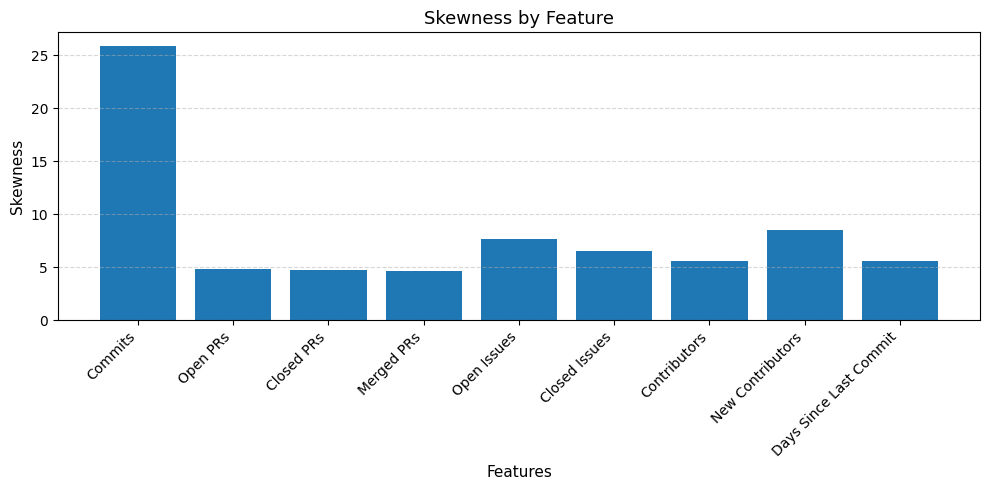

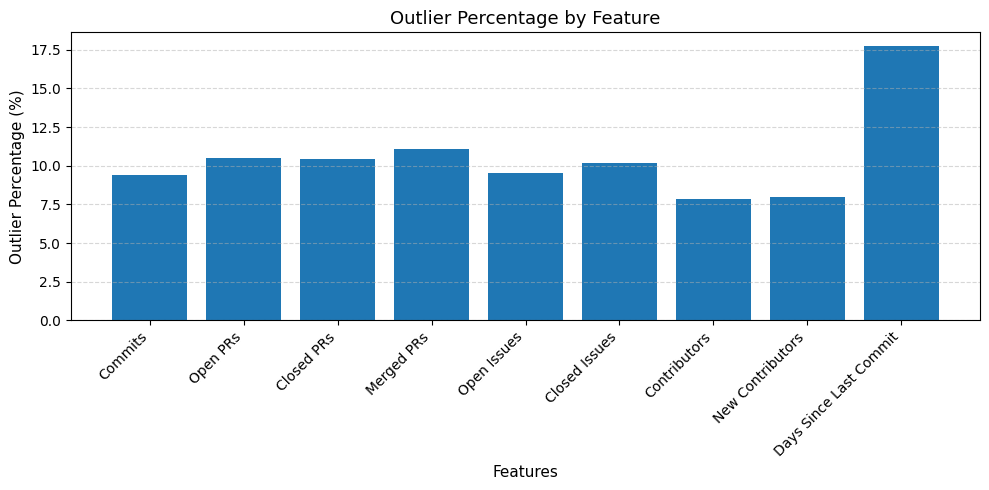

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 1. LOAD DATA
# =========================================
df = pd.read_csv("panel_dataset.csv")

# =========================================
# 2. CHỌN CÁC BIẾN SỐ
# =========================================
features = [
    "number_of_commits",
    "number_of_open_PRs",
    "number_of_closed_PRs",
    "number_of_merged_PRs",
    "number_of_open_issues",
    "number_of_closed_issues",
    "number_of_contributors",
    "number_of_new_contributors",
    "days_since_last_commit"
]

labels = {
    "number_of_commits": "Commits",
    "number_of_open_PRs": "Open PRs",
    "number_of_closed_PRs": "Closed PRs",
    "number_of_merged_PRs": "Merged PRs",
    "number_of_open_issues": "Open Issues",
    "number_of_closed_issues": "Closed Issues",
    "number_of_contributors": "Contributors",
    "number_of_new_contributors": "New Contributors",
    "days_since_last_commit": "Days Since Last Commit"
}

# =========================================
# 3. TÍNH SKEWNESS VÀ OUTLIER %
# =========================================
skewness_values = []
outlier_percentages = []
feature_names = []

for col in features:
    data = df[col].dropna()

    # Skewness
    skew_val = data.skew()

    # IQR outlier percentage
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    outlier_pct = (len(outliers) / len(data)) * 100

    skewness_values.append(skew_val)
    outlier_percentages.append(outlier_pct)
    feature_names.append(labels[col])

# =========================================
# 4. VẼ BIỂU ĐỒ SKEWNESS
# =========================================
plt.figure(figsize=(10, 5))
plt.bar(feature_names, skewness_values)
plt.title("Skewness by Feature", fontsize=13)
plt.ylabel("Skewness", fontsize=11)
plt.xlabel("Features", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("skewness_barchart.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================
# 5. VẼ BIỂU ĐỒ OUTLIER %
# =========================================
plt.figure(figsize=(10, 5))
plt.bar(feature_names, outlier_percentages)
plt.title("Outlier Percentage by Feature", fontsize=13)
plt.ylabel("Outlier Percentage (%)", fontsize=11)
plt.xlabel("Features", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("outlier_percentage_barchart.png", dpi=300, bbox_inches="tight")
plt.show()

Saved: yearly_activity_summary.csv
   year  observations  total_commits  total_open_prs  total_closed_prs  \
0  2020           672          58016           19816             18921   
1  2021          1867         142307           56407             54472   
2  2022          2776         250696          114465            111560   
3  2023          4145         403820          207773            200763   
4  2024          5296         499551          297701            291209   
5  2025          6547         650787          420190            401717   

   total_merged_prs  total_open_issues  total_closed_issues  \
0             15816              19317                14042   
1             46107              63650                45826   
2             91592             130134                92081   
3            164195             231897               174591   
4            239147             285305               234901   
5            310107             354942               292767   

   t

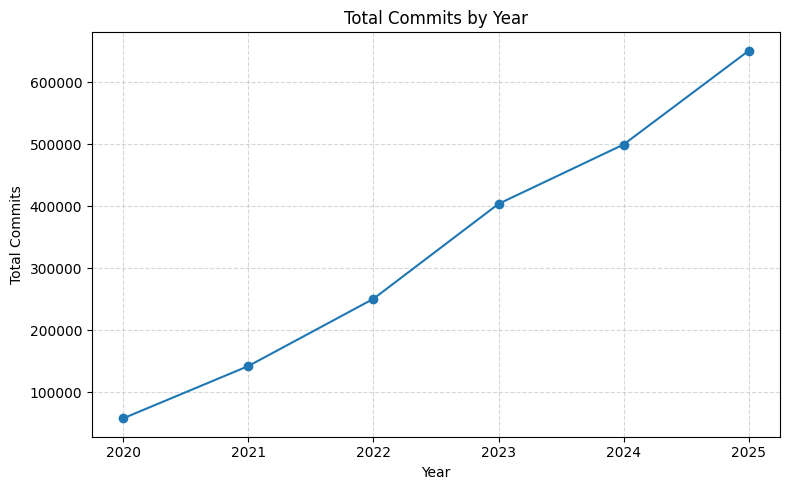

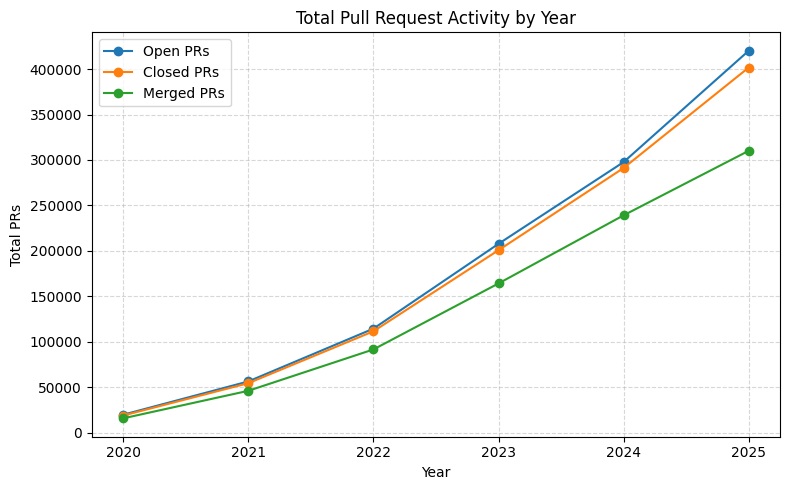

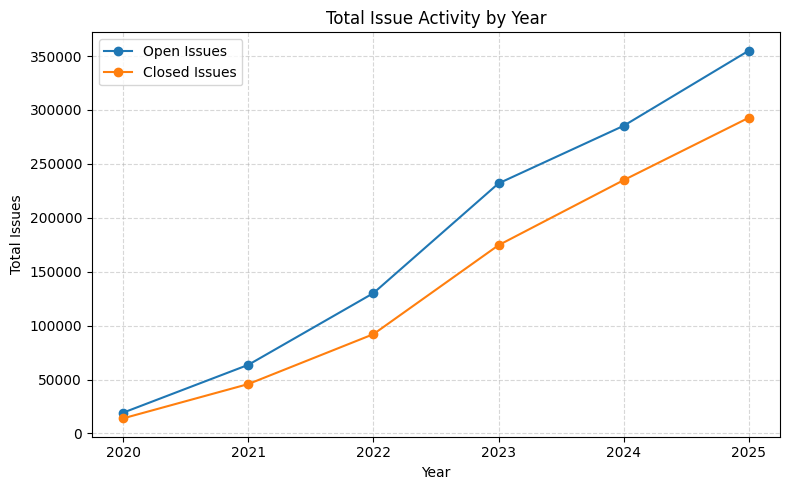

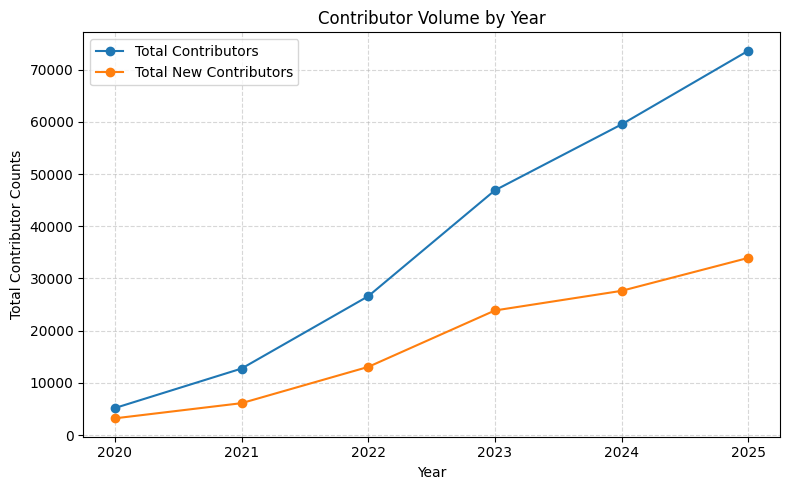

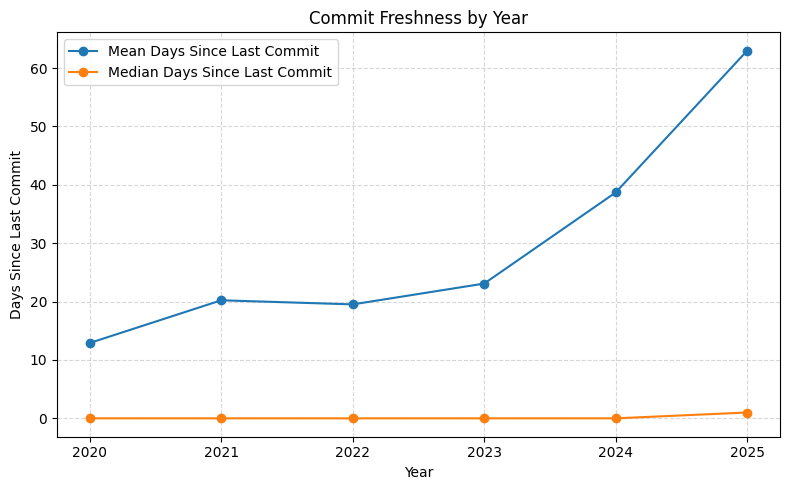

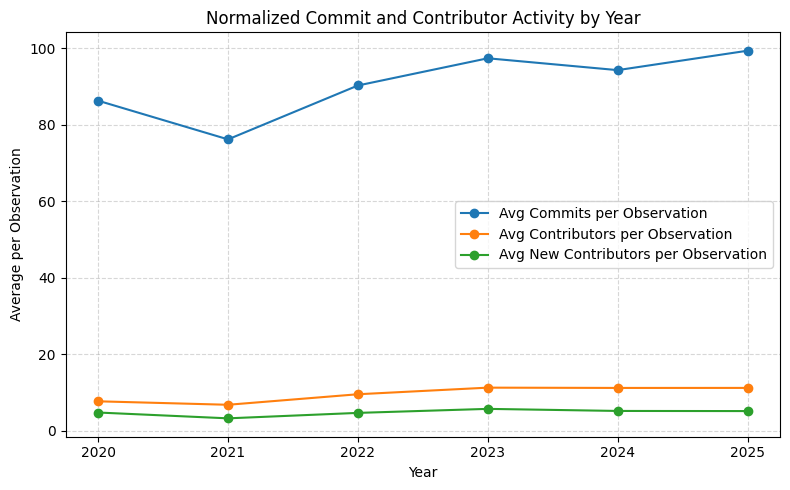

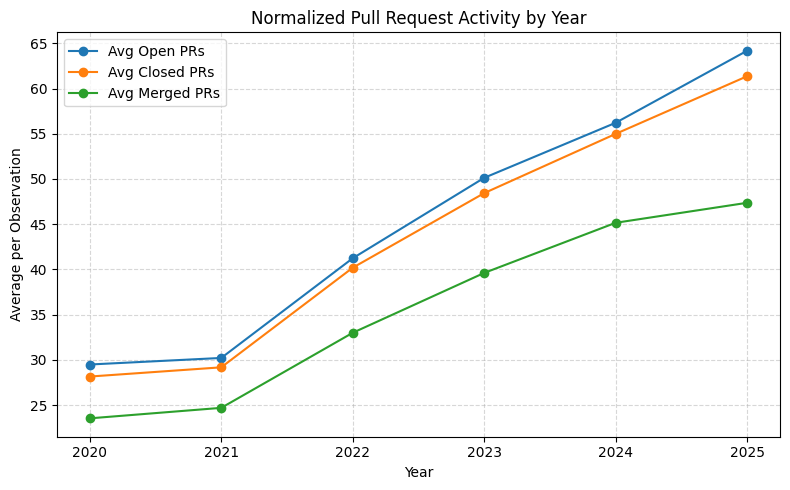

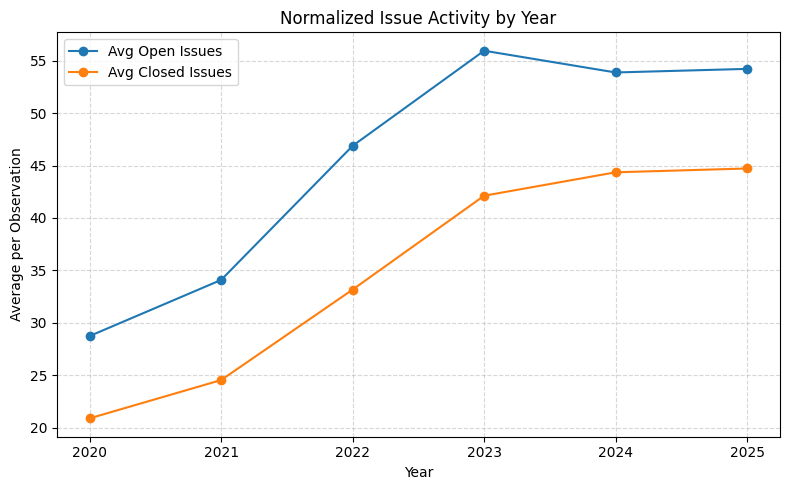

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# 1. LOAD DATA
# =========================================
df = pd.read_csv("panel_dataset.csv")

# =========================================
# 2. ENSURE YEAR COLUMN
# =========================================
if "year" not in df.columns:
    if "date" in df.columns:
        # expected format like Jan-21
        df["year"] = pd.to_datetime(df["date"], format="%b-%y", errors="coerce").dt.year
    elif "month_end_dt" in df.columns:
        df["year"] = pd.to_datetime(df["month_end_dt"], errors="coerce").dt.year
    else:
        raise ValueError("No 'year', 'date', or 'month_end_dt' column found.")

df = df.dropna(subset=["year"]).copy()
df["year"] = df["year"].astype(int)

# =========================================
# 3. NUMERIC COLUMNS
# =========================================
numeric_cols = [
    "number_of_commits",
    "number_of_open_PRs",
    "number_of_closed_PRs",
    "number_of_merged_PRs",
    "number_of_open_issues",
    "number_of_closed_issues",
    "number_of_contributors",
    "number_of_new_contributors",
    "days_since_last_commit",
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================================
# 4. AGGREGATE TOTALS BY YEAR
# =========================================
yearly_total = df.groupby("year").agg(
    observations=("year", "size"),
    total_commits=("number_of_commits", "sum"),
    total_open_prs=("number_of_open_PRs", "sum"),
    total_closed_prs=("number_of_closed_PRs", "sum"),
    total_merged_prs=("number_of_merged_PRs", "sum"),
    total_open_issues=("number_of_open_issues", "sum"),
    total_closed_issues=("number_of_closed_issues", "sum"),
    total_contributors=("number_of_contributors", "sum"),
    total_new_contributors=("number_of_new_contributors", "sum"),
    mean_days_since_last_commit=("days_since_last_commit", "mean"),
    median_days_since_last_commit=("days_since_last_commit", "median"),
).reset_index()

# =========================================
# 5. NORMALIZE PER OBSERVATION
# =========================================
yearly_total["avg_commits_per_observation"] = (
    yearly_total["total_commits"] / yearly_total["observations"]
)

yearly_total["avg_contributors_per_observation"] = (
    yearly_total["total_contributors"] / yearly_total["observations"]
)

yearly_total["avg_new_contributors_per_observation"] = (
    yearly_total["total_new_contributors"] / yearly_total["observations"]
)

yearly_total["avg_open_prs_per_observation"] = (
    yearly_total["total_open_prs"] / yearly_total["observations"]
)

yearly_total["avg_closed_prs_per_observation"] = (
    yearly_total["total_closed_prs"] / yearly_total["observations"]
)

yearly_total["avg_merged_prs_per_observation"] = (
    yearly_total["total_merged_prs"] / yearly_total["observations"]
)

yearly_total["avg_open_issues_per_observation"] = (
    yearly_total["total_open_issues"] / yearly_total["observations"]
)

yearly_total["avg_closed_issues_per_observation"] = (
    yearly_total["total_closed_issues"] / yearly_total["observations"]
)

# =========================================
# 6. SAVE SUMMARY TABLE
# =========================================
yearly_total.to_csv("yearly_activity_summary.csv", index=False)
print("Saved: yearly_activity_summary.csv")
print(yearly_total)

# =========================================
# 7. PLOT 1: TOTAL COMMITS BY YEAR
# =========================================
plt.figure(figsize=(8, 5))
plt.plot(yearly_total["year"], yearly_total["total_commits"], marker="o")
plt.title("Total Commits by Year")
plt.xlabel("Year")
plt.ylabel("Total Commits")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("total_commits_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================
# 8. PLOT 2: TOTAL PR ACTIVITY BY YEAR
# =========================================
plt.figure(figsize=(8, 5))
plt.plot(yearly_total["year"], yearly_total["total_open_prs"], marker="o", label="Open PRs")
plt.plot(yearly_total["year"], yearly_total["total_closed_prs"], marker="o", label="Closed PRs")
plt.plot(yearly_total["year"], yearly_total["total_merged_prs"], marker="o", label="Merged PRs")
plt.title("Total Pull Request Activity by Year")
plt.xlabel("Year")
plt.ylabel("Total PRs")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("total_pr_activity_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================
# 9. PLOT 3: TOTAL ISSUE ACTIVITY BY YEAR
# =========================================
plt.figure(figsize=(8, 5))
plt.plot(yearly_total["year"], yearly_total["total_open_issues"], marker="o", label="Open Issues")
plt.plot(yearly_total["year"], yearly_total["total_closed_issues"], marker="o", label="Closed Issues")
plt.title("Total Issue Activity by Year")
plt.xlabel("Year")
plt.ylabel("Total Issues")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("total_issue_activity_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================
# 10. PLOT 4: TOTAL CONTRIBUTORS BY YEAR
# =========================================
plt.figure(figsize=(8, 5))
plt.plot(yearly_total["year"], yearly_total["total_contributors"], marker="o", label="Total Contributors")
plt.plot(yearly_total["year"], yearly_total["total_new_contributors"], marker="o", label="Total New Contributors")
plt.title("Contributor Volume by Year")
plt.xlabel("Year")
plt.ylabel("Total Contributor Counts")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("total_contributors_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================
# 11. PLOT 5: COMMIT FRESHNESS BY YEAR
# =========================================
plt.figure(figsize=(8, 5))
plt.plot(
    yearly_total["year"],
    yearly_total["mean_days_since_last_commit"],
    marker="o",
    label="Mean Days Since Last Commit"
)
plt.plot(
    yearly_total["year"],
    yearly_total["median_days_since_last_commit"],
    marker="o",
    label="Median Days Since Last Commit"
)
plt.title("Commit Freshness by Year")
plt.xlabel("Year")
plt.ylabel("Days Since Last Commit")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("commit_freshness_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================
# 12. PLOT 6: NORMALIZED COMMITS / CONTRIBUTORS
# =========================================
plt.figure(figsize=(8, 5))
plt.plot(yearly_total["year"], yearly_total["avg_commits_per_observation"], marker="o", label="Avg Commits per Observation")
plt.plot(yearly_total["year"], yearly_total["avg_contributors_per_observation"], marker="o", label="Avg Contributors per Observation")
plt.plot(yearly_total["year"], yearly_total["avg_new_contributors_per_observation"], marker="o", label="Avg New Contributors per Observation")
plt.title("Normalized Commit and Contributor Activity by Year")
plt.xlabel("Year")
plt.ylabel("Average per Observation")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("normalized_commits_contributors_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================
# 13. PLOT 7: NORMALIZED PR ACTIVITY
# =========================================
plt.figure(figsize=(8, 5))
plt.plot(yearly_total["year"], yearly_total["avg_open_prs_per_observation"], marker="o", label="Avg Open PRs")
plt.plot(yearly_total["year"], yearly_total["avg_closed_prs_per_observation"], marker="o", label="Avg Closed PRs")
plt.plot(yearly_total["year"], yearly_total["avg_merged_prs_per_observation"], marker="o", label="Avg Merged PRs")
plt.title("Normalized Pull Request Activity by Year")
plt.xlabel("Year")
plt.ylabel("Average per Observation")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("normalized_pr_activity_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================
# 14. PLOT 8: NORMALIZED ISSUE ACTIVITY
# =========================================
plt.figure(figsize=(8, 5))
plt.plot(yearly_total["year"], yearly_total["avg_open_issues_per_observation"], marker="o", label="Avg Open Issues")
plt.plot(yearly_total["year"], yearly_total["avg_closed_issues_per_observation"], marker="o", label="Avg Closed Issues")
plt.title("Normalized Issue Activity by Year")
plt.xlabel("Year")
plt.ylabel("Average per Observation")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("normalized_issue_activity_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

Saved: monthly_activity_summary.csv
   year  month year_month_dt  observations  total_commits  total_contributors  \
0  2020      1    2020-01-01             9            846                  63   
1  2020      2    2020-02-01            16           2147                 109   
2  2020      3    2020-03-01            25           3532                 130   
3  2020      4    2020-04-01            33           3449                 190   
4  2020      5    2020-05-01            45           5679                 469   

   mean_days_since_last_commit  median_days_since_last_commit  \
0                     3.777778                            0.0   
1                     4.875000                            0.0   
2                     6.291667                            0.0   
3                     9.312500                            0.0   
4                     8.720930                            0.0   

   avg_commits_per_observation  avg_contributors_per_observation  
0                  

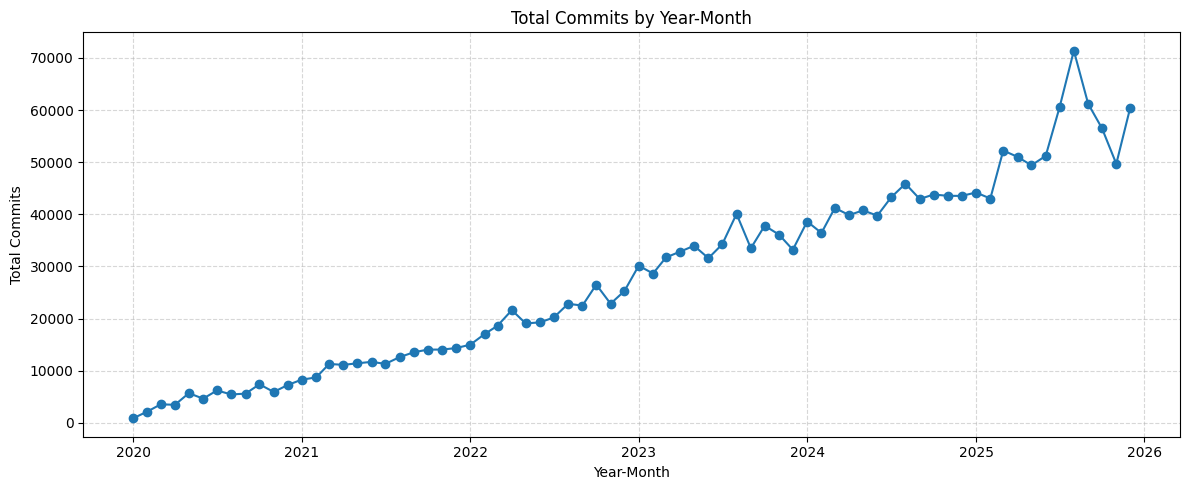

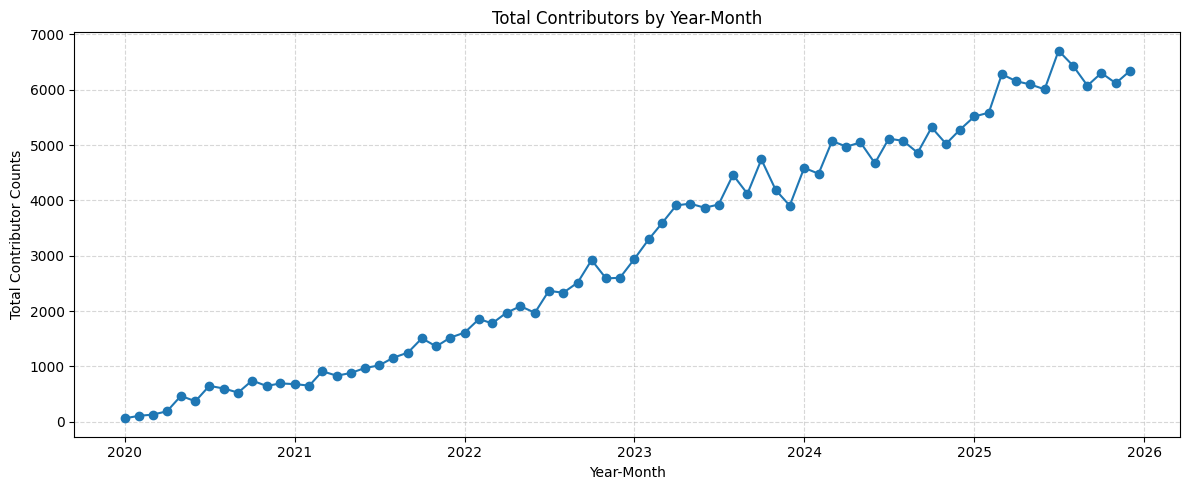

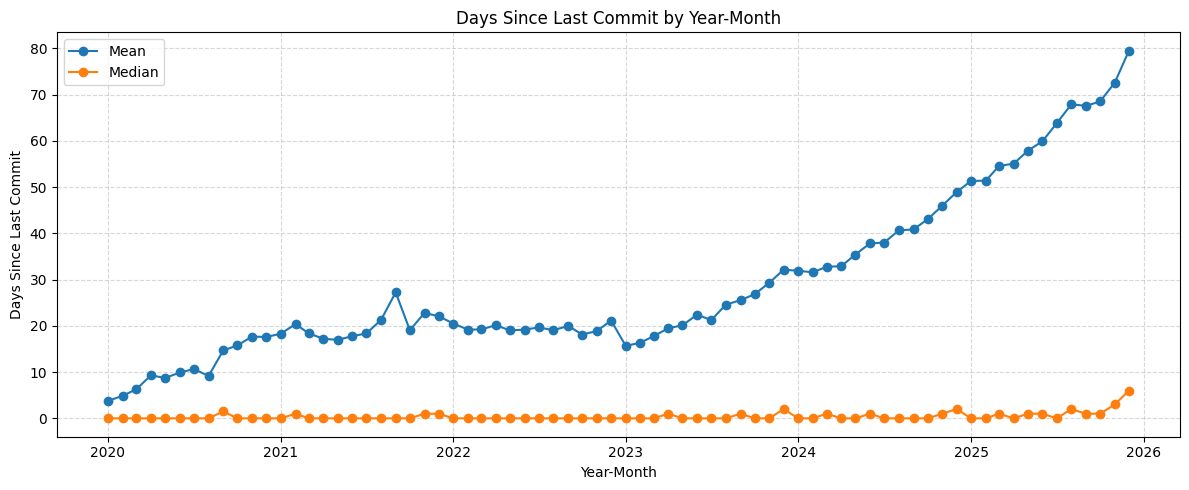

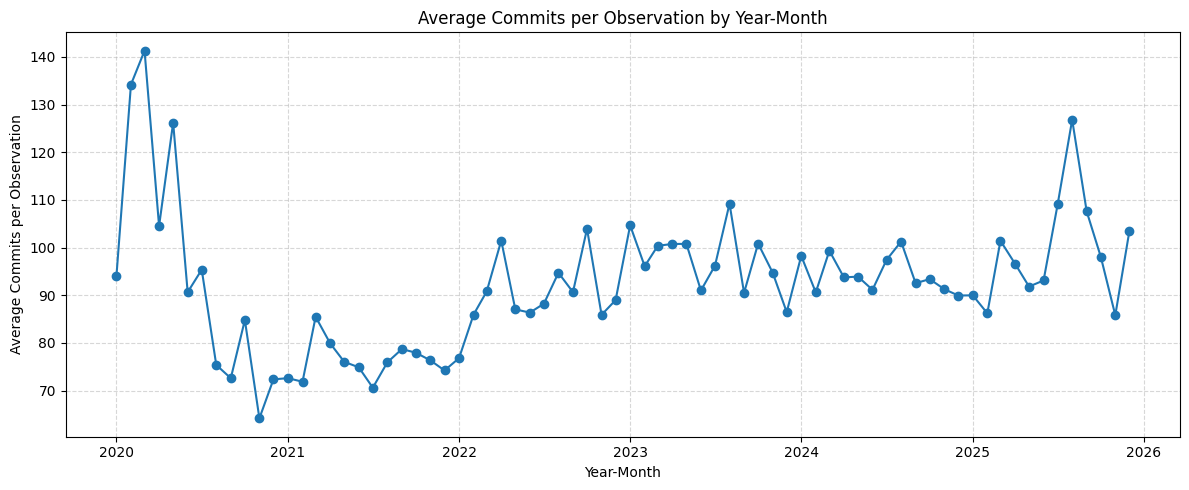

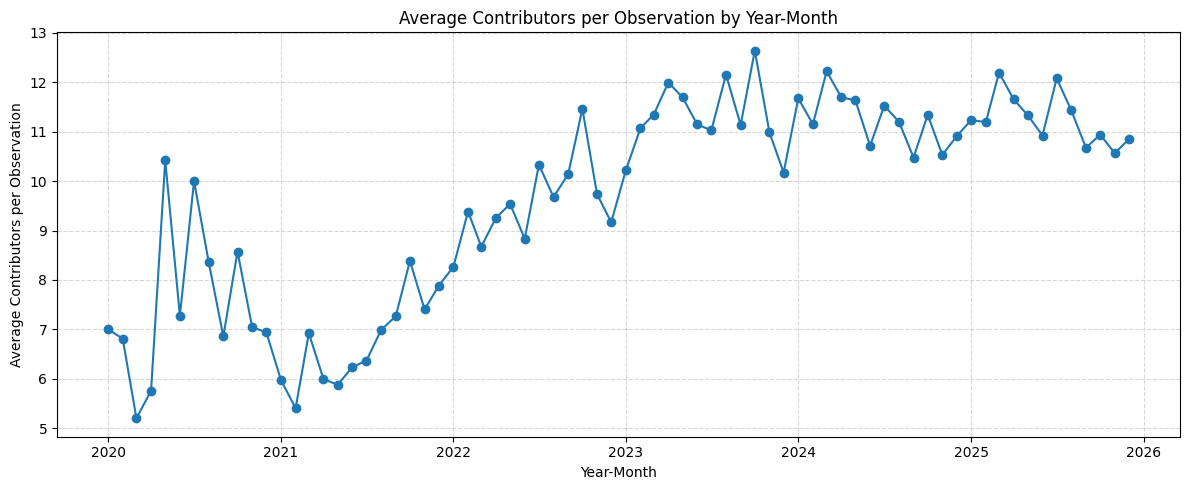

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# 1. LOAD DATA
# =========================================
df = pd.read_csv("panel_dataset.csv")

# =========================================
# 2. USE EXISTING year AND month COLUMNS
# =========================================
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["month"] = pd.to_numeric(df["month"], errors="coerce")

df = df.dropna(subset=["year", "month"]).copy()
df["year"] = df["year"].astype(int)
df["month"] = df["month"].astype(int)

# tạo cột datetime để sort và vẽ biểu đồ
df["year_month_dt"] = pd.to_datetime(
    df["year"].astype(str) + "-" + df["month"].astype(str).str.zfill(2) + "-01"
)

# =========================================
# 3. CONVERT NUMERIC COLUMNS
# =========================================
numeric_cols = [
    "number_of_commits",
    "number_of_contributors",
    "days_since_last_commit"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================================
# 4. AGGREGATE BY YEAR-MONTH
# =========================================
monthly_summary = df.groupby(["year", "month", "year_month_dt"]).agg(
    observations=("year", "size"),
    total_commits=("number_of_commits", "sum"),
    total_contributors=("number_of_contributors", "sum"),
    mean_days_since_last_commit=("days_since_last_commit", "mean"),
    median_days_since_last_commit=("days_since_last_commit", "median")
).reset_index()

monthly_summary = monthly_summary.sort_values("year_month_dt")

# =========================================
# 5. NORMALIZE PER OBSERVATION
# =========================================
monthly_summary["avg_commits_per_observation"] = (
    monthly_summary["total_commits"] / monthly_summary["observations"]
)

monthly_summary["avg_contributors_per_observation"] = (
    monthly_summary["total_contributors"] / monthly_summary["observations"]
)

# =========================================
# 6. SAVE SUMMARY
# =========================================
monthly_summary.to_csv("monthly_activity_summary.csv", index=False)
print("Saved: monthly_activity_summary.csv")
print(monthly_summary.head())

# =========================================
# 7. PLOT: TOTAL COMMITS BY YEAR-MONTH
# =========================================
plt.figure(figsize=(12, 5))
plt.plot(monthly_summary["year_month_dt"], monthly_summary["total_commits"], marker="o")
plt.title("Total Commits by Year-Month")
plt.xlabel("Year-Month")
plt.ylabel("Total Commits")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("monthly_total_commits.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================
# 8. PLOT: TOTAL CONTRIBUTORS BY YEAR-MONTH
# =========================================
plt.figure(figsize=(12, 5))
plt.plot(monthly_summary["year_month_dt"], monthly_summary["total_contributors"], marker="o")
plt.title("Total Contributors by Year-Month")
plt.xlabel("Year-Month")
plt.ylabel("Total Contributor Counts")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("monthly_total_contributors.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================
# 9. PLOT: DAYS SINCE LAST COMMIT BY YEAR-MONTH
# =========================================
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_summary["year_month_dt"],
    monthly_summary["mean_days_since_last_commit"],
    marker="o",
    label="Mean"
)
plt.plot(
    monthly_summary["year_month_dt"],
    monthly_summary["median_days_since_last_commit"],
    marker="o",
    label="Median"
)
plt.title("Days Since Last Commit by Year-Month")
plt.xlabel("Year-Month")
plt.ylabel("Days Since Last Commit")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("monthly_days_since_last_commit.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================
# 10. PLOT: NORMALIZED COMMITS BY YEAR-MONTH
# =========================================
plt.figure(figsize=(12, 5))
plt.plot(monthly_summary["year_month_dt"], monthly_summary["avg_commits_per_observation"], marker="o")
plt.title("Average Commits per Observation by Year-Month")
plt.xlabel("Year-Month")
plt.ylabel("Average Commits per Observation")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("monthly_avg_commits_per_observation.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================
# 11. PLOT: NORMALIZED CONTRIBUTORS BY YEAR-MONTH
# =========================================
plt.figure(figsize=(12, 5))
plt.plot(monthly_summary["year_month_dt"], monthly_summary["avg_contributors_per_observation"], marker="o")
plt.title("Average Contributors per Observation by Year-Month")
plt.xlabel("Year-Month")
plt.ylabel("Average Contributors per Observation")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("monthly_avg_contributors_per_observation.png", dpi=300, bbox_inches="tight")
plt.show()

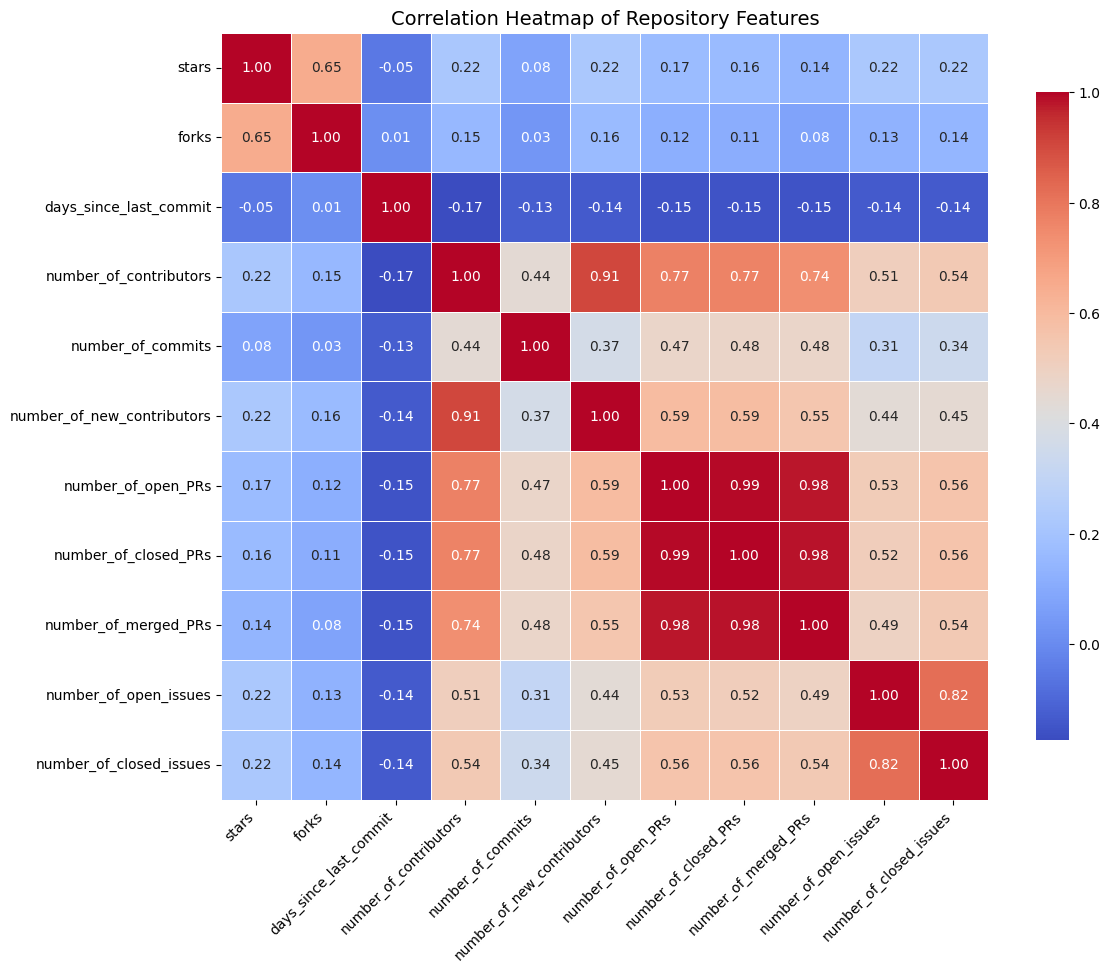

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# 1. LOAD DATA
# =========================================
df = pd.read_csv("panel_dataset.csv")

# =========================================
# 2. CHỌN CÁC BIẾN
# =========================================
cols = [
    
    "stars",
    "forks",
    "days_since_last_commit",
    "number_of_contributors",
    "number_of_commits",
    "number_of_new_contributors",
    "number_of_open_PRs",
    "number_of_closed_PRs",
    "number_of_merged_PRs",
    "number_of_open_issues",
    "number_of_closed_issues"
]

# =========================================
# 3. TÍNH CORRELATION MATRIX
# =========================================
corr_matrix = df[cols].corr()

# =========================================
# 4. VẼ HEATMAP
# =========================================
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap of Repository Features", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# =========================================
# 5. SAVE
# =========================================
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

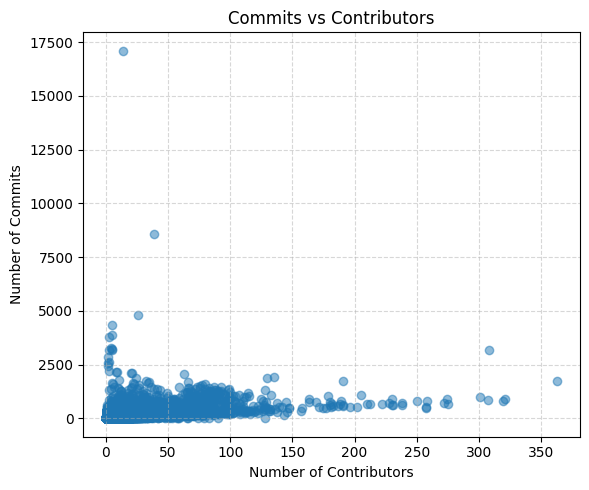

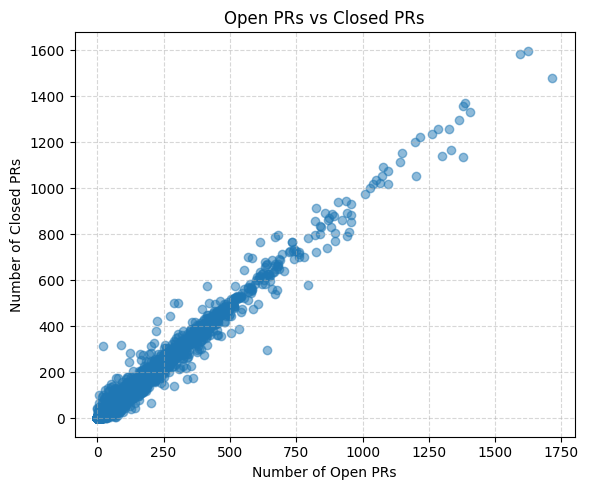

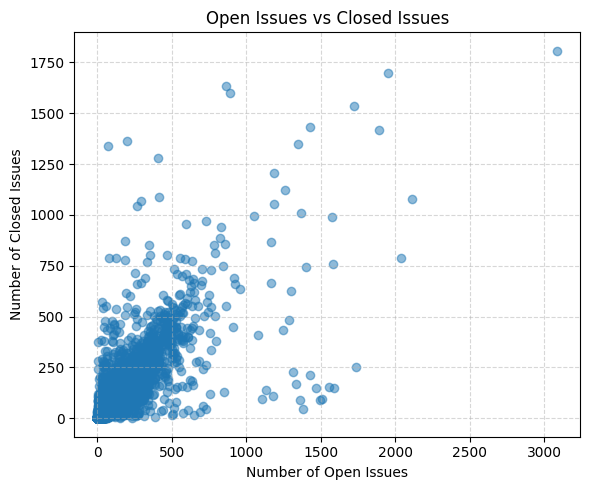

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# 1. LOAD DATA
# =========================================
df = pd.read_csv("panel_dataset.csv")

# =========================================
# 2. DEFINE VARIABLE PAIRS
# =========================================
pairs = [
    ("number_of_contributors", "number_of_commits"),
    ("number_of_open_PRs", "number_of_closed_PRs"),
    ("number_of_open_issues", "number_of_closed_issues")
]

labels = {
    "number_of_contributors": "Number of Contributors",
    "number_of_commits": "Number of Commits",
    "number_of_open_PRs": "Number of Open PRs",
    "number_of_closed_PRs": "Number of Closed PRs",
    "number_of_open_issues": "Number of Open Issues",
    "number_of_closed_issues": "Number of Closed Issues"
}

titles = {
    ("number_of_contributors", "number_of_commits"): "Commits vs Contributors",
    ("number_of_open_PRs", "number_of_closed_PRs"): "Open PRs vs Closed PRs",
    ("number_of_open_issues", "number_of_closed_issues"): "Open Issues vs Closed Issues"
}

file_names = {
    ("number_of_contributors", "number_of_commits"): "scatter_commits_vs_contributors.png",
    ("number_of_open_PRs", "number_of_closed_PRs"): "scatter_open_vs_closed_prs.png",
    ("number_of_open_issues", "number_of_closed_issues"): "scatter_open_vs_closed_issues.png"
}

# =========================================
# 3. CREATE AND SAVE EACH SCATTER PLOT
# =========================================
for x_col, y_col in pairs:
    plot_data = df[[x_col, y_col]].dropna()

    plt.figure(figsize=(6, 5))
    plt.scatter(plot_data[x_col], plot_data[y_col], alpha=0.5)
    plt.title(titles[(x_col, y_col)], fontsize=12)
    plt.xlabel(labels[x_col], fontsize=10)
    plt.ylabel(labels[y_col], fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(file_names[(x_col, y_col)], dpi=300, bbox_inches="tight")
    plt.show()